<a href="https://colab.research.google.com/github/Simran1604/Neuromorphic-EuroSAT-SNN/blob/main/Neuromorphic_Eurosat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install snntorch

import torch
import torchvision
import torchvision.transforms as transforms
from snntorch import spikegen
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 4.8 MB/s eta 0:00:00


In [4]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

print("Downloading EuroSAT dataset...")
eurosat_data = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

print(f"Dataset downloaded successfully! Total images: {len(eurosat_data)}")

sample_image, sample_label = eurosat_data[0]
print(f"Sample image shape: {sample_image.shape}")

100%|██████████| 94.3M/94.3M [00:00<00:00, 159MB/s]


Dataset downloaded successfully! Total images: 27000
Sample image shape: torch.Size([3, 64, 64])


In [5]:
num_steps = 25

spike_data = spikegen.rate(sample_image, num_steps=num_steps)

print(f"Spike data shape: {spike_data.shape}")

Spike data shape: torch.Size([25, 3, 64, 64])


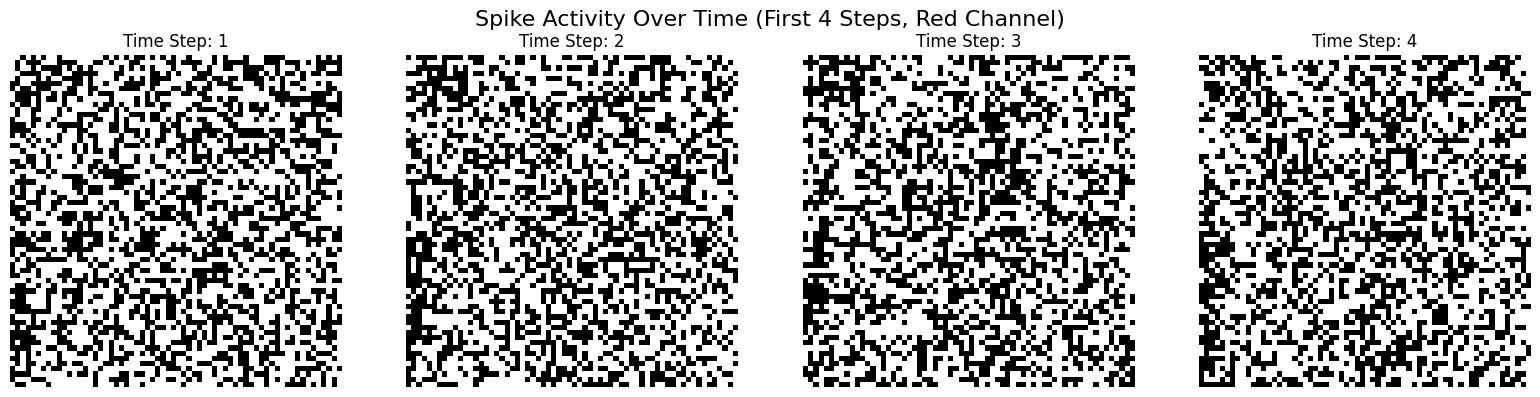

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Spike Activity Over Time (First 4 Steps, Red Channel)", fontsize=16)

for i in range(4):
    spike_frame = spike_data[i, 0].numpy()

    ax = axes[i]
    cax = ax.imshow(spike_frame, cmap='binary')
    ax.set_title(f"Time Step: {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

beta = 0.9
spike_grad = surrogate.fast_sigmoid()

In [8]:
class CSNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 12, 5)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.conv2 = nn.Conv2d(12, 32, 5)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)

        self.fc = nn.Linear(32 * 13 * 13, 10)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk3_rec = []
        mem3_rec = []

        for step in range(x.size(0)):
            cur1 = nn.functional.max_pool2d(self.conv1(x[step]), 2)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = nn.functional.max_pool2d(self.conv2(spk1), 2)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc(spk2.view(spk2.size(0), -1))
            spk3, mem3 = self.lif3(cur3, mem3)

            spk3_rec.append(spk3)
            mem3_rec.append(mem3)

        return torch.stack(spk3_rec), torch.stack(mem3_rec)

In [9]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")

net = CSNN().to(device)

print(net)

Using device: cuda
CSNN(
  (conv1): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1))
  (lif1): Leaky()
  (conv2): Conv2d(12, 32, kernel_size=(5, 5), stride=(1, 1))
  (lif2): Leaky()
  (fc): Linear(in_features=5408, out_features=10, bias=True)
  (lif3): Leaky()
)


In [10]:
from torch.utils.data import DataLoader, random_split

train_size = int(0.8 * len(eurosat_data))
test_size = len(eurosat_data) - train_size
train_dataset, test_dataset = random_split(eurosat_data, [train_size, test_size])

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

Training batches: 675
Testing batches: 168


In [11]:
import torch.optim as optim
from snntorch import functional as SF

optimizer = optim.Adam(net.parameters(), lr=2e-3, betas=(0.9, 0.999))

loss_fn = SF.ce_rate_loss()

In [12]:
num_epochs = 5
loss_hist = []
acc_hist = []

print("Starting SNN Training...")

for epoch in range(num_epochs):
    net.train()
    train_batch_loss = 0
    correct = 0
    total = 0

    for i, (data, targets) in enumerate(train_loader):
        data = data.to(device)
        targets = targets.to(device)

        spike_data = spikegen.rate(data, num_steps=num_steps)

        spk_rec, mem_rec = net(spike_data)

        loss = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_batch_loss += loss.item()

        _, predicted = spk_rec.sum(dim=0).max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        if i % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    epoch_acc = 100 * correct / total
    epoch_loss = train_batch_loss / len(train_loader)

    loss_hist.append(epoch_loss)
    acc_hist.append(epoch_acc)

    print(f"--> Epoch {epoch+1} Completed | Average Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")

Starting SNN Training...
Epoch 1/5 | Batch 0/675 | Loss: 2.3017
Epoch 1/5 | Batch 100/675 | Loss: 2.4607
Epoch 1/5 | Batch 200/675 | Loss: 2.3734
Epoch 1/5 | Batch 300/675 | Loss: 2.3477
Epoch 1/5 | Batch 400/675 | Loss: 2.4648
Epoch 1/5 | Batch 500/675 | Loss: 2.4008
Epoch 1/5 | Batch 600/675 | Loss: 2.4908
--> Epoch 1 Completed | Average Loss: 2.4014 | Accuracy: 11.37%

Epoch 2/5 | Batch 0/675 | Loss: 2.4917
Epoch 2/5 | Batch 100/675 | Loss: 2.4321
Epoch 2/5 | Batch 200/675 | Loss: 2.6115
Epoch 2/5 | Batch 300/675 | Loss: 2.4312
Epoch 2/5 | Batch 400/675 | Loss: 2.4615
Epoch 2/5 | Batch 500/675 | Loss: 2.4917
Epoch 2/5 | Batch 600/675 | Loss: 2.4299
--> Epoch 2 Completed | Average Loss: 2.4136 | Accuracy: 11.25%

Epoch 3/5 | Batch 0/675 | Loss: 2.2417
Epoch 3/5 | Batch 100/675 | Loss: 2.2191
Epoch 3/5 | Batch 200/675 | Loss: 2.3915
Epoch 3/5 | Batch 300/675 | Loss: 2.1519
Epoch 3/5 | Batch 400/675 | Loss: 2.0445
Epoch 3/5 | Batch 500/675 | Loss: 2.1574
Epoch 3/5 | Batch 600/675 | Los

In [13]:
print("--- Hardware Efficiency Evaluation ---")

net.eval()

data, targets = next(iter(test_loader))
data = data.to(device)

spike_data = spikegen.rate(data, num_steps=num_steps)

with torch.no_grad():
    spk_out, _ = net(spike_data)

total_possible_spikes = spk_out.numel()
actual_spikes = spk_out.sum().item()

firing_rate = actual_spikes / total_possible_spikes

print(f"Total possible computations (Standard Dense ANN): {total_possible_spikes}")
print(f"Actual computations executed (Our Sparse SNN): {actual_spikes}")
print(f"Network Firing Rate: {firing_rate * 100:.2f}% (Lower is better!)\n")


ann_energy = total_possible_spikes * 4.6
snn_energy = actual_spikes * 0.9

print(f"Estimated Energy Cost (Standard ANN): {ann_energy:.2f} pJ")
print(f"Estimated Energy Cost (Our SNN):      {snn_energy:.2f} pJ")

savings = 100 - (snn_energy / ann_energy * 100)
print(f"-> Total Estimated Energy Savings: {savings:.2f}%")

--- Hardware Efficiency Evaluation ---
Total possible computations (Standard Dense ANN): 8000
Actual computations executed (Our Sparse SNN): 0.0
Network Firing Rate: 0.00% (Lower is better!)

Estimated Energy Cost (Standard ANN): 36800.00 pJ
Estimated Energy Cost (Our SNN):      0.00 pJ
-> Total Estimated Energy Savings: 100.00%
